In [1]:
# Import libraries

from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing"
)

OCR_PATH = PROJECT_ROOT / "outputs" / "ocr"

CLEANED_PATH = PROJECT_ROOT / "outputs" / "cleaned"

NER_PATH = PROJECT_ROOT / "outputs" / "ner"

MODEL_OUTPUT_PATH = PROJECT_ROOT / "outputs" / "model_testing"

In [3]:
MODEL_OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Model testing output folder ready.")

Model testing output folder ready.


In [4]:
def load_json(file_path):

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as file:

        return json.load(file)

In [5]:
invoice_ner = load_json(
    NER_PATH / "invoice_entities.json"
)

resume_ner = load_json(
    NER_PATH / "resume_entities.json"
)

id_card_ner = load_json(
    NER_PATH / "id_card_entities.json"
)

In [6]:
print(
    "Invoices:",
    len(invoice_ner)
)

print(
    "Resumes:",
    len(resume_ner)
)

print(
    "ID Cards:",
    len(id_card_ner)
)

Invoices: 3
Resumes: 2
ID Cards: 3


In [7]:
sample_invoice_name = list(
    invoice_ner.keys()
)[0]

print(
    json.dumps(
        invoice_ner[sample_invoice_name],
        indent=4,
        ensure_ascii=False
    )
)

{
    "document_type": "invoice",
    "entities": {
        "emails": [],
        "phone_numbers": [],
        "dates": [],
        "amounts": [],
        "spacy_entities": {
            "ORG": [
                "55,57 & S9",
                "SAGU I8",
                "Cashier"
            ],
            "PERSON": [
                "TAMAN DAYA",
                "Acljustnienl"
            ],
            "CARDINAL": [
                "81100",
                "25/12p2018",
                "8",
                "13.39",
                "1",
                "9.00",
                "0,C0",
                "0.00",
                "0o"
            ],
            "MONEY": [
                "# #ii"
            ]
        },
        "invoice_number": null,
        "gstin": []
    }
}


In [8]:
sample_resume_name = list(
    resume_ner.keys()
)[0]

print(
    json.dumps(
        resume_ner[sample_resume_name],
        indent=4,
        ensure_ascii=False
    )
)

{
    "document_type": "resume",
    "entities": {
        "emails": [],
        "phone_numbers": [],
        "dates": [],
        "amounts": [],
        "spacy_entities": {
            "PERSON": [
                "Diana Dawa",
                "Mukaa"
            ],
            "CARDINAL": [
                "4"
            ],
            "ORG": [
                "Data Sdendtt\nTECHNICAL"
            ]
        },
        "persons": [
            "Diana Dawa",
            "Mukaa"
        ],
        "organizations": [
            "Data Sdendtt\nTECHNICAL"
        ],
        "locations": []
    }
}


In [9]:
sample_id_name = list(
    id_card_ner.keys()
)[0]

print(
    json.dumps(
        id_card_ner[sample_id_name],
        indent=4,
        ensure_ascii=False
    )
)

{
    "document_type": "id_card",
    "entities": {
        "emails": [],
        "phone_numbers": [],
        "dates": [
            "31/10/1992"
        ],
        "amounts": [],
        "spacy_entities": {
            "ORG": [
                "NNCOHE TAXDEPAMHENT\n",
                "GOVT OF NNDIA"
            ],
            "PERSON": [
                "MAHADEV SHINDE",
                "Accounl Numbcr"
            ]
        },
        "persons": [
            "MAHADEV SHINDE",
            "Accounl Numbcr"
        ],
        "id_numbers": []
    }
}


In [10]:
INVOICE_FIELDS = [
    "emails",
    "phone_numbers",
    "dates",
    "amounts",
    "invoice_number",
    "gstin"
]

In [11]:
RESUME_FIELDS = [
    "emails",
    "phone_numbers",
    "persons",
    "organizations",
    "locations"
]

In [12]:
ID_CARD_FIELDS = [
    "persons",
    "dates",
    "id_numbers"
]

In [13]:
# Helper function

def field_has_value(value):

    if value is None:
        return False

    if isinstance(value, list):

        return len(value) > 0

    if isinstance(value, str):

        return bool(value.strip())

    return bool(value)

In [14]:
print(field_has_value("Mohan"))
print(field_has_value([]))
print(field_has_value(["Mohan"]))
print(field_has_value(None))

True
False
True
False


In [15]:
# Calculate field coverage

def calculate_field_coverage(
    results,
    required_fields,
    document_type
):

    rows = []

    for filename, data in results.items():

        entities = data["entities"]

        total_fields = len(
            required_fields
        )

        detected_fields = 0

        field_status = {}

        for field in required_fields:

            value = entities.get(
                field
            )

            detected = field_has_value(
                value
            )

            field_status[field] = detected

            if detected:
                detected_fields += 1

        coverage = (
            detected_fields /
            total_fields
            if total_fields > 0
            else 0
        )

        row = {
            "filename": filename,
            "document_type": document_type,
            "detected_fields":
                detected_fields,
            "total_expected_fields":
                total_fields,
            "field_coverage":
                coverage
        }

        row.update(
            field_status
        )

        rows.append(row)

    return pd.DataFrame(rows)

In [16]:
# Evaluate invoices

invoice_evaluation = calculate_field_coverage(
    invoice_ner,
    INVOICE_FIELDS,
    "Invoice"
)

invoice_evaluation

,filename,document_type,detected_fields,total_expected_fields,field_coverage,emails,phone_numbers,dates,amounts,invoice_number,gstin
0,X00016469612.txt,Invoice,0,6,0.000000,False,False,False,False,False,False
1,X00016469620.txt,Invoice,1,6,0.166667,False,False,True,False,False,False
2,X00016469622.txt,Invoice,0,6,0.000000,False,False,False,False,False,False


In [17]:
# Evaluate resumes

resume_evaluation = calculate_field_coverage(
    resume_ner,
    RESUME_FIELDS,
    "Resume"
)

resume_evaluation

,filename,document_type,detected_fields,total_expected_fields,field_coverage,emails,phone_numbers,persons,organizations,locations
0,Image_1.txt,Resume,2,5,0.4,False,False,True,True,False
1,Image_10.txt,Resume,1,5,0.2,False,False,False,True,False


In [18]:
# Evaluate ID cards

id_card_evaluation = calculate_field_coverage(
    id_card_ner,
    ID_CARD_FIELDS,
    "ID Card"
)

id_card_evaluation

,filename,document_type,detected_fields,total_expected_fields,field_coverage,persons,dates,id_numbers
0,0005_jpeg_jpg.rf.252590ac8ae7f0f84a08f15a164d6...,ID Card,2,3,0.666667,True,True,False
1,0521_adhar_jpg.rf.0188ba6593c38a70e56de2509a24...,ID Card,1,3,0.333333,False,False,True
2,0521_adhar_jpg.rf.0b52a68eba1d0f3ea5d868a66390...,ID Card,1,3,0.333333,False,False,True


In [19]:
# Combine evaluation results

evaluation_df = pd.concat(
    [
        invoice_evaluation,
        resume_evaluation,
        id_card_evaluation
    ],
    ignore_index=True
)

evaluation_df

,filename,document_type,detected_fields,total_expected_fields,field_coverage,emails,phone_numbers,dates,amounts,invoice_number,gstin,persons,organizations,locations,id_numbers
0,X00016469612.txt,Invoice,0,6,0.000000,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,X00016469620.txt,Invoice,1,6,0.166667,False,False,True,False,False,False,NaN,NaN,NaN,NaN
2,X00016469622.txt,Invoice,0,6,0.000000,False,False,False,False,False,False,NaN,NaN,NaN,NaN
3,Image_1.txt,Resume,2,5,0.400000,False,False,NaN,NaN,NaN,NaN,True,True,False,NaN
4,Image_10.txt,Resume,1,5,0.200000,False,False,NaN,NaN,NaN,NaN,False,True,False,NaN
5,0005_jpeg_jpg.rf.252590ac8ae7f0f84a08f15a164d6...,ID Card,2,3,0.666667,NaN,NaN,True,NaN,NaN,NaN,True,NaN,NaN,False
6,0521_adhar_jpg.rf.0188ba6593c38a70e56de2509a24...,ID Card,1,3,0.333333,NaN,NaN,False,NaN,NaN,NaN,False,NaN,NaN,True
7,0521_adhar_jpg.rf.0b52a68eba1d0f3ea5d868a66390...,ID Card,1,3,0.333333,NaN,NaN,False,NaN,NaN,NaN,False,NaN,NaN,True


In [20]:
# Overall field coverage

overall_coverage = (
    evaluation_df[
        "field_coverage"
    ].mean()
)

print(
    f"Overall field coverage: "
    f"{overall_coverage:.2%}"
)

Overall field coverage: 26.25%


In [21]:
# Coverage by document type

document_coverage = (
    evaluation_df
    .groupby("document_type")
    ["field_coverage"]
    .mean()
)

print(document_coverage)

document_type
ID Card    0.444444
Invoice    0.055556
Resume     0.300000
Name: field_coverage, dtype: float64


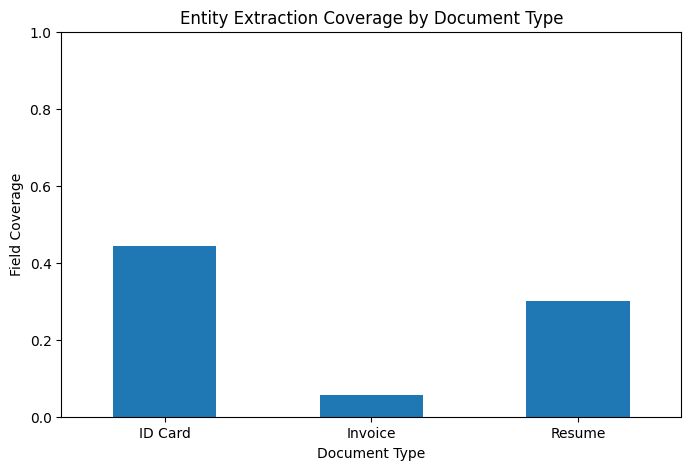

In [22]:
# Plot document coverage

document_coverage.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Entity Extraction Coverage by Document Type"
)

plt.xlabel("Document Type")

plt.ylabel("Field Coverage")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.show()

In [23]:
# Field-level performance

def calculate_field_performance(
    evaluation_df,
    fields
):

    results = []

    for field in fields:

        if field in evaluation_df.columns:

            detection_rate = (
                evaluation_df[field]
                .mean()
            )

            results.append({
                "field": field,
                "detection_rate":
                    detection_rate
            })

    return pd.DataFrame(results)

In [24]:
invoice_field_performance = (
    calculate_field_performance(
        invoice_evaluation,
        INVOICE_FIELDS
    )
)

invoice_field_performance

,field,detection_rate
0,emails,0.000000
1,phone_numbers,0.000000
2,dates,0.333333
3,amounts,0.000000
4,invoice_number,0.000000
5,gstin,0.000000


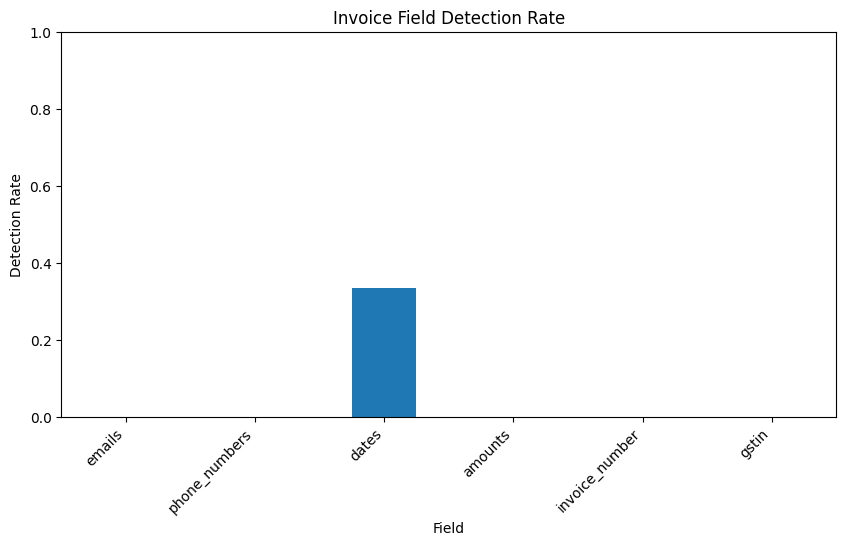

In [25]:
# Plot invoice field detection

invoice_field_performance.set_index(
    "field"
)["detection_rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Invoice Field Detection Rate"
)

plt.xlabel("Field")

plt.ylabel("Detection Rate")

plt.ylim(0, 1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.show()

In [26]:
# Resume field performance

resume_field_performance = (
    calculate_field_performance(
        resume_evaluation,
        RESUME_FIELDS
    )
)

resume_field_performance

,field,detection_rate
0,emails,0.0
1,phone_numbers,0.0
2,persons,0.5
3,organizations,1.0
4,locations,0.0


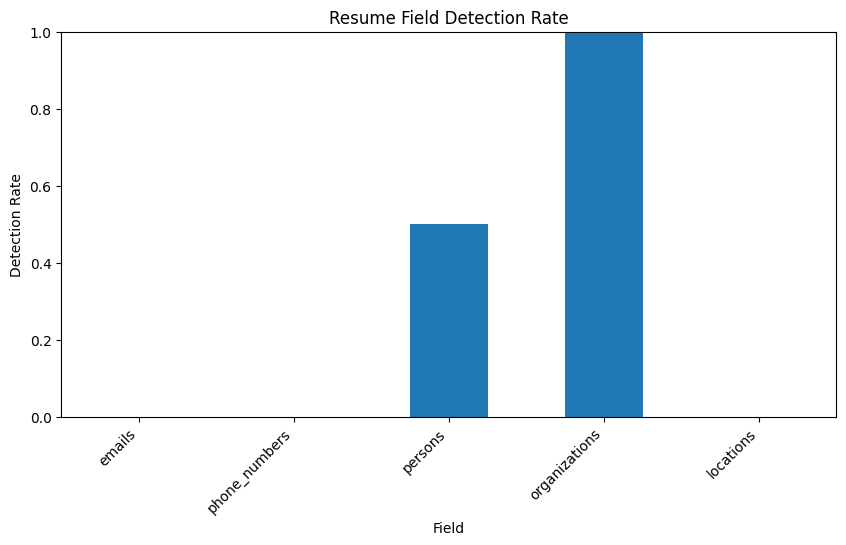

In [27]:
resume_field_performance.set_index(
    "field"
)["detection_rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Resume Field Detection Rate"
)

plt.xlabel("Field")

plt.ylabel("Detection Rate")

plt.ylim(0, 1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.show()

In [28]:
# ID-card field performance

id_field_performance = (
    calculate_field_performance(
        id_card_evaluation,
        ID_CARD_FIELDS
    )
)

id_field_performance

,field,detection_rate
0,persons,0.333333
1,dates,0.333333
2,id_numbers,0.666667


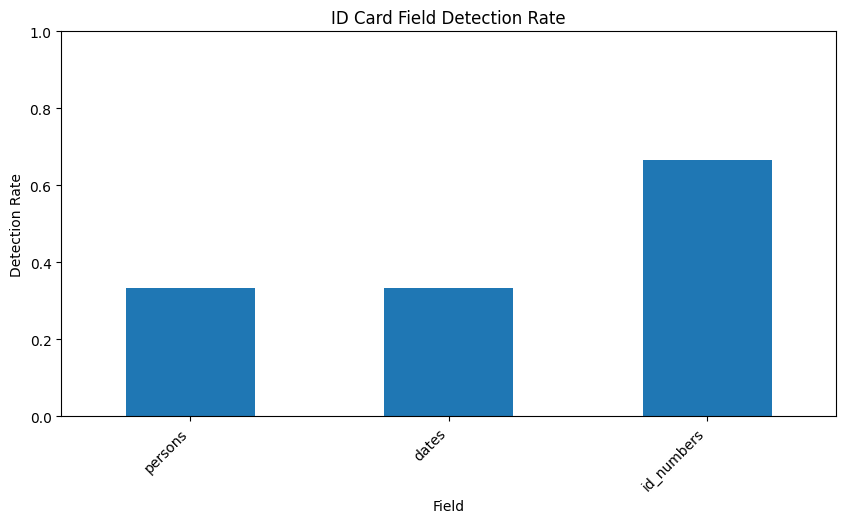

In [29]:
id_field_performance.set_index(
    "field"
)["detection_rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "ID Card Field Detection Rate"
)

plt.xlabel("Field")

plt.ylabel("Detection Rate")

plt.ylim(0, 1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.show()

In [30]:
# Find weak documents

weak_documents = evaluation_df[
    evaluation_df["field_coverage"] < 0.50
].copy()

print(
    "Documents with less than 50% field coverage:"
)

weak_documents

Documents with less than 50% field coverage:


,filename,document_type,detected_fields,total_expected_fields,field_coverage,emails,phone_numbers,dates,amounts,invoice_number,gstin,persons,organizations,locations,id_numbers
0,X00016469612.txt,Invoice,0,6,0.000000,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,X00016469620.txt,Invoice,1,6,0.166667,False,False,True,False,False,False,NaN,NaN,NaN,NaN
2,X00016469622.txt,Invoice,0,6,0.000000,False,False,False,False,False,False,NaN,NaN,NaN,NaN
3,Image_1.txt,Resume,2,5,0.400000,False,False,NaN,NaN,NaN,NaN,True,True,False,NaN
4,Image_10.txt,Resume,1,5,0.200000,False,False,NaN,NaN,NaN,NaN,False,True,False,NaN
6,0521_adhar_jpg.rf.0188ba6593c38a70e56de2509a24...,ID Card,1,3,0.333333,NaN,NaN,False,NaN,NaN,NaN,False,NaN,NaN,True
7,0521_adhar_jpg.rf.0b52a68eba1d0f3ea5d868a66390...,ID Card,1,3,0.333333,NaN,NaN,False,NaN,NaN,NaN,False,NaN,NaN,True


In [31]:
# Find strong documents

strong_documents = evaluation_df[
    evaluation_df["field_coverage"] >= 0.80
].copy()

print(
    "Documents with 80% or higher field coverage:"
)

strong_documents

Documents with 80% or higher field coverage:


,filename,document_type,detected_fields,total_expected_fields,field_coverage,emails,phone_numbers,dates,amounts,invoice_number,gstin,persons,organizations,locations,id_numbers


In [32]:
error_analysis = evaluation_df[
    ["filename",
     "document_type",
     "field_coverage"]
].copy()

error_analysis["status"] = np.where(
    error_analysis["field_coverage"] >= 0.80,
    "Good",
    np.where(
        error_analysis["field_coverage"] >= 0.50,
        "Needs Review",
        "Poor"
    )
)

error_analysis

,filename,document_type,field_coverage,status
0,X00016469612.txt,Invoice,0.000000,Poor
1,X00016469620.txt,Invoice,0.166667,Poor
2,X00016469622.txt,Invoice,0.000000,Poor
3,Image_1.txt,Resume,0.400000,Poor
4,Image_10.txt,Resume,0.200000,Poor
5,0005_jpeg_jpg.rf.252590ac8ae7f0f84a08f15a164d6...,ID Card,0.666667,Needs Review
6,0521_adhar_jpg.rf.0188ba6593c38a70e56de2509a24...,ID Card,0.333333,Poor
7,0521_adhar_jpg.rf.0b52a68eba1d0f3ea5d868a66390...,ID Card,0.333333,Poor


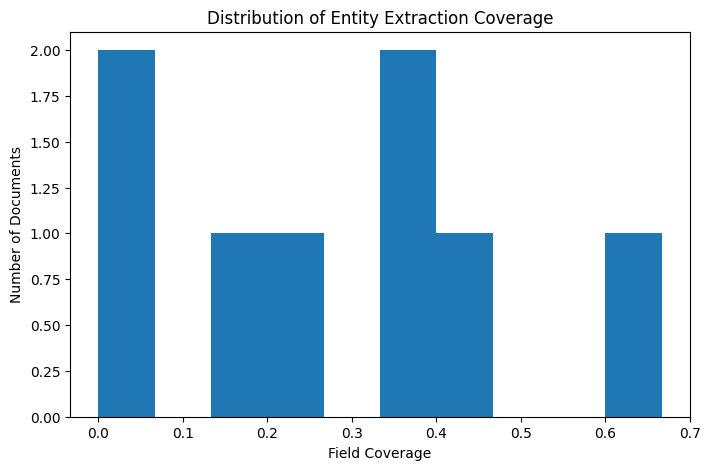

In [33]:
evaluation_df[
    "field_coverage"
].plot(
    kind="hist",
    bins=10,
    figsize=(8, 5)
)

plt.title(
    "Distribution of Entity Extraction Coverage"
)

plt.xlabel(
    "Field Coverage"
)

plt.ylabel(
    "Number of Documents"
)

plt.show()

In [34]:
# Overall performance summary

performance_summary = pd.DataFrame({
    "Metric": [
        "Documents Evaluated",
        "Overall Field Coverage",
        "Invoice Coverage",
        "Resume Coverage",
        "ID Card Coverage"
    ],

    "Value": [
        len(evaluation_df),

        overall_coverage,

        invoice_evaluation[
            "field_coverage"
        ].mean(),

        resume_evaluation[
            "field_coverage"
        ].mean(),

        id_card_evaluation[
            "field_coverage"
        ].mean()
    ]
})

performance_summary

,Metric,Value
0,Documents Evaluated,8.000000
1,Overall Field Coverage,0.262500
2,Invoice Coverage,0.055556
3,Resume Coverage,0.300000
4,ID Card Coverage,0.444444


In [35]:
# Format percentages

performance_summary_display = (
    performance_summary.copy()
)

percentage_rows = [
    "Overall Field Coverage",
    "Invoice Coverage",
    "Resume Coverage",
    "ID Card Coverage"
]

for row in percentage_rows:

    performance_summary_display.loc[
        performance_summary_display["Metric"] == row,
        "Value"
    ] = (
        performance_summary_display.loc[
            performance_summary_display["Metric"] == row,
            "Value"
        ].astype(float) * 100
    ).round(2).astype(str) + "%"

performance_summary_display

/tmp/ipykernel_1130/1085570818.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['26.25%']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  performance_summary_display.loc[


,Metric,Value
0,Documents Evaluated,8.0
1,Overall Field Coverage,26.25%
2,Invoice Coverage,5.56%
3,Resume Coverage,30.0%
4,ID Card Coverage,44.44%


In [36]:
# Save evaluation results

evaluation_df.to_csv(
    MODEL_OUTPUT_PATH /
    "entity_extraction_evaluation.csv",
    index=False
)

In [37]:
performance_summary.to_csv(
    MODEL_OUTPUT_PATH /
    "performance_summary.csv",
    index=False
)

In [38]:
error_analysis.to_csv(
    MODEL_OUTPUT_PATH /
    "error_analysis.csv",
    index=False
)

In [39]:
# Save JSON report

evaluation_report = {
    "overall_field_coverage":
        float(overall_coverage),

    "document_count":
        int(len(evaluation_df)),

    "invoice_coverage":
        float(
            invoice_evaluation[
                "field_coverage"
            ].mean()
        ),

    "resume_coverage":
        float(
            resume_evaluation[
                "field_coverage"
            ].mean()
        ),

    "id_card_coverage":
        float(
            id_card_evaluation[
                "field_coverage"
            ].mean()
        )
}

In [40]:
with open(
    MODEL_OUTPUT_PATH /
    "evaluation_report.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        evaluation_report,
        file,
        indent=4
    )

print("Evaluation report saved.")

Evaluation report saved.
